In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
data = pd.read_csv('lab_day_5_dataset.csv')

X = data.select_dtypes(include=np.number)
X = X.drop(columns=['Dropout','Stress_Index','Travel_Time_Minutes'])
y = data['Dropout']

In [11]:
from IPython.display import Markdown
def performance(X,message):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    display(Markdown(f'***{message}***'))
    display(Markdown(f"**Accuracy Score :** {accuracy_score(y_test,y_pred)}"))
    print(f"**Classification Report :** \n{classification_report(y_test,y_pred)}")

In [16]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
scaler_standard = StandardScaler()
X_train_standard = scaler_standard.fit_transform(X)
print(X_train_standard[:5])
performance(X_train_standard,'Scalar Standard without PCA')

[[ 0.66261622 -1.00220243 -0.64528217 -0.51824878  0.53076578 -1.22372485
  -0.73557427 -1.30420473 -1.35506318 -1.18429046 -1.41371618]
 [-0.27833269 -1.00220243 -0.64528217  0.22579404 -1.67104177  0.81717717
  -0.73557427 -1.03380874  0.43521715  0.01669368 -0.71159739]
 [ 0.66261622 -1.00220243  0.11141476  0.30494753 -1.31826597 -1.22372485
  -0.73557427 -0.91259674 -1.35506318  1.21767782 -1.41371618]
 [ 1.60356512 -1.00220243 -0.43501382  0.1387252   0.05634316  0.81717717
  -0.73557427 -0.49301675 -1.35506318 -1.18429046 -0.0094786 ]
 [-0.27833269  0.99780241 -0.62938371  0.1387252  -0.73436121  0.81717717
  -0.73557427 -1.33217673  1.33035731  0.01669368  0.69264018]]


***Scalar Standard without PCA***

**Accuracy Score :** 0.7305

**Classification Report :** 
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1545
           1       0.44      0.72      0.55       455

    accuracy                           0.73      2000
   macro avg       0.67      0.73      0.68      2000
weighted avg       0.79      0.73      0.75      2000



In [15]:
standard_scaler = StandardScaler()
x_scaled = standard_scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))
performance(X_pca,'Scalar Standard with PCA')

Explained Variance Ratio: [0.1162293  0.09643006]
Total Variance Retained: 0.21265935570202843


***Scalar Standard with PCA***

**Accuracy Score :** 0.6915

**Classification Report :** 
              precision    recall  f1-score   support

           0       0.89      0.68      0.77      1545
           1       0.40      0.71      0.51       455

    accuracy                           0.69      2000
   macro avg       0.65      0.70      0.64      2000
weighted avg       0.78      0.69      0.71      2000



In [6]:
do = data['Dropout'].unique().tolist()
do_map = {
    do[0] : 'Non-DropOut',
    do[1] : 'DropOut'
}

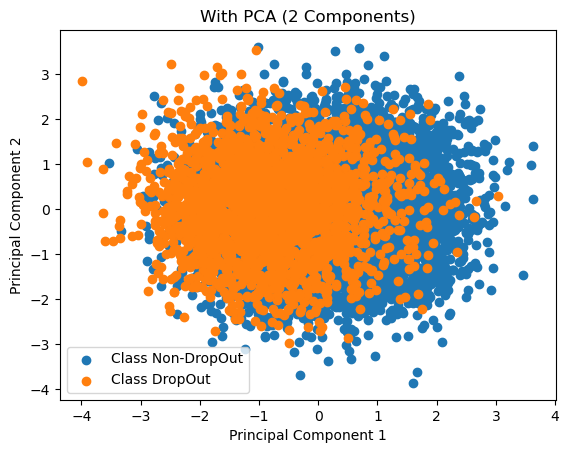

In [7]:
plt.figure()

for label in [0,1]:
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        label=f"Class {do_map[label]}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("With PCA (2 Components)")
plt.legend()
plt.show()

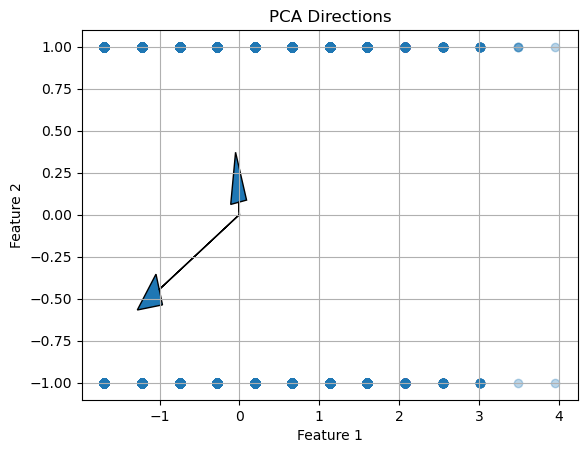

In [8]:
plt.figure()
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], alpha=0.3)
# Plot PCA components
for i, component in enumerate(pca.components_):
    plt.arrow(
        0, 0,
        component[0]*3,
        component[1]*3,
        head_width=0.2
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("PCA Directions")
plt.grid()
plt.show()

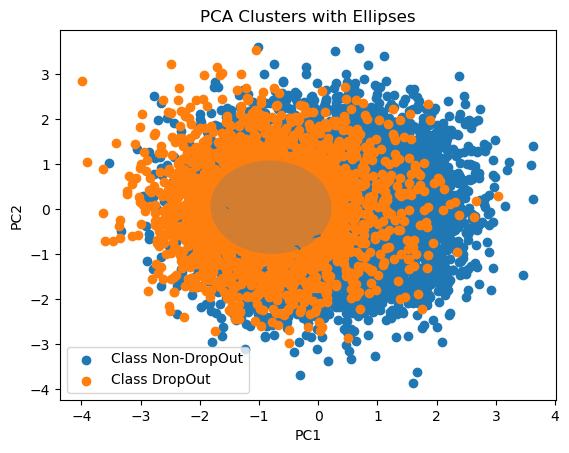

In [9]:
import matplotlib.patches as patches
import numpy.linalg as LA
plt.figure()

for label in np.unique(y):
    subset = X_pca[y == label]
    plt.scatter(subset[:, 0], subset[:, 1], label=f"Class {do_map[label]}")
    cov = np.cov(subset.T)
    mean = subset.mean(axis=0) 
    eigvals, eigvecs = LA.eig(cov)   
    angle = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))
    width, height = 2 * np.sqrt(eigvals)
    
    ellipse = patches.Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        alpha=0.2
    )
    
    plt.gca().add_patch(ellipse)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Clusters with Ellipses")
plt.legend()
plt.show()

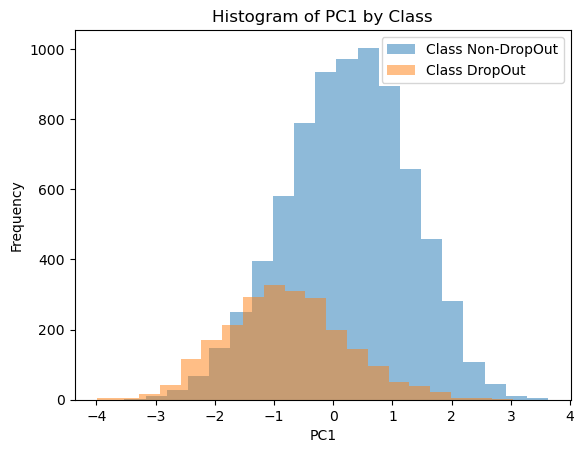

In [13]:
plt.figure()

for label in np.unique(y):
    subset = X_pca[y == label]
    plt.hist(subset[:,0], bins=20, alpha=0.5, label=f"Class {do_map[label]}")

plt.xlabel("PC1")
plt.ylabel("Frequency")
plt.title("Histogram of PC1 by Class")
plt.legend()
plt.show()